Exercise 4 WorkSheet

In [68]:
import pandas as pd
from sqlalchemy import create_engine, text

In [69]:
engine = create_engine(
    "postgresql+psycopg2://jakieldavid@localhost:5432/worldMYSQL.sql"
)

In [70]:
connection = engine.connect()

In [71]:
result = connection.execute(text("SELECT * FROM country LIMIT 5"))

df = pd.DataFrame(result.fetchall(), columns=result.keys())

df

,code,name,continent,region,surfacearea,indepyear,population,lifeexpectancy,gnp,gnpold,localname,governmentform,headofstate,capital,code2
0,ABW,Aruba ...,North America ...,Caribbean,193.00,NaN,103000,78.4,828.00,793.00,Aruba,Nonmetropolitan Territory of The Netherlands,Beatrix ...,129,AW
1,AFG,Afghanistan ...,Asia ...,Southern and Central Asia,652090.00,1919.0,22720000,45.9,5976.00,None,Afganistan/Afqanestan,Islamic Emirate,Mohammad Omar ...,1,AF
2,AGO,Angola ...,Africa ...,Central Africa,1246700.00,1975.0,12878000,38.3,6648.00,7984.00,Angola,Republic,José Eduardo dos Santos ...,56,AO
3,AIA,Anguilla ...,North America ...,Caribbean,96.00,NaN,8000,76.1,63.20,None,Anguilla,Dependent Territory of the UK,Elisabeth II ...,62,AI
4,ALB,Albania ...,Europe ...,Southern Europe,28748.00,1912.0,3401200,71.6,3205.00,2500.00,Shqipëria,Republic,Rexhep Mejdani ...,34,AL


In [53]:
result = connection.execute(
    text("""
SELECT country.Name,
       COUNT(countrylanguage.Language) AS Number_Official_Languages
FROM country
JOIN countrylanguage
    ON country.Code = countrylanguage.CountryCode
WHERE countrylanguage.isofficial = 'T'
GROUP BY country.Name
HAVING COUNT(countrylanguage.Language) > 2
ORDER BY Number_Official_Languages DESC;
""")
)

In [ ]:
result = connection.execute(
    text("""
SELECT country.Name,
       COUNT(countrylanguage.Language) AS Number_of_Languages
FROM country
JOIN countrylanguage
    ON country.Code = countrylanguage.CountryCode
GROUP BY country.Name
HAVING COUNT(countrylanguage.Language) > 9
ORDER BY Number_of_Languages DESC;
""")
)

In [86]:
df = pd.DataFrame(data=result.fetchall(), columns=result.keys())
df

,name,number_of_languages
0,Canada ...,12
1,China ...,12
2,India ...,12
3,United States ...,12
4,Russian Federation ...,12
5,Tanzania ...,11
6,South Africa ...,11
7,Mozambique ...,10
8,Philippines ...,10
9,Nigeria ...,10


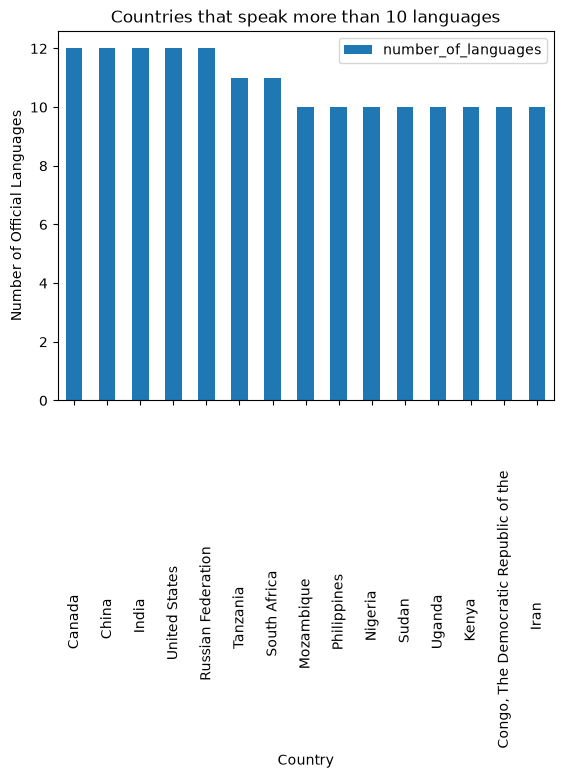

In [ ]:
import matplotlib.pyplot as plt

df.plot(
    x="name",
    y="number_of_languages",
    kind="bar",
)

plt.xlabel("Country")
plt.ylabel("Number of Official Languages")
plt.title("Countries that speak more than 10 languages")
plt.show()

InternalError: (psycopg2.errors.InFailedSqlTransaction) current transaction is aborted, commands ignored until end of transaction block

[SQL: 
SELECT country.Name,
       COUNT(countrylanguage.Language) AS Number_of_Languages
FROM country
JOIN countrylanguage
    ON country.Code = countrylanguage.CountryCode
GROUP BY country.Name
HAVING COUNT(countrylanguage.Language) > 5
ORDER BY Number_of_Languages DESC;
]
(Background on this error at: https://sqlalche.me/e/20/2j85)

In [63]:
df = pd.DataFrame(data=result.fetchall(), columns=result.keys())
df

,country,number_of_languages
0,India ...,12
1,Canada ...,12
2,United States ...,12
3,China ...,12
4,Russian Federation ...,12
...,...,...
228,Portugal ...,1
229,San Marino ...,1
230,Montserrat ...,1
231,Grenada ...,1
